In [1]:
from pathlib import Path

# Project root
PROJECT_DIR = Path.cwd().parent

# Raw freight index directory
FREIGHT_DIR = PROJECT_DIR / "data" / "raw" / "freight_indices"

print("Freight directory:")
print(FREIGHT_DIR)

print("\nFolder exists:", FREIGHT_DIR.exists())

Freight directory:
C:\Users\pradi\OneDrive\Desktop\Freight rate forecasting ML project\data\raw\freight_indices

Folder exists: True


In [2]:
# ============================================================
# FREIGHTIQ — MODEL 1
# TASK 1: COMBINE FREIGHT INDEX DATA
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Load BDI parts
# ------------------------------------------------------------

bdi_1 = pd.read_csv(
    FREIGHT_DIR / "Baltic Dry Index" / "BDI_1985-2000.csv"
)

bdi_2 = pd.read_csv(
    FREIGHT_DIR / "Baltic Dry Index" / "BDI_2001-2016.csv"
)

bdi_3 = pd.read_csv(
    FREIGHT_DIR / "Baltic Dry Index" / "BDI_2017-2026.csv"
)

# Combine BDI
bdi = pd.concat(
    [bdi_1, bdi_2, bdi_3],
    ignore_index=True
)

# Keep required columns only
bdi = bdi[["Date", "Price"]].copy()

# Convert data types
bdi["Date"] = pd.to_datetime(
    bdi["Date"],
    errors="coerce"
)

bdi["Price"] = (
    bdi["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Remove duplicate dates
bdi = (
    bdi
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .reset_index(drop=True)
)

# Rename target
bdi = bdi.rename(columns={"Price": "BDI"})


# ------------------------------------------------------------
# 2. Load BCI parts
# ------------------------------------------------------------

bci_1 = pd.read_csv(
    FREIGHT_DIR / "Baltic Capesize" / "2012-2017.csv"
)

bci_2 = pd.read_csv(
    FREIGHT_DIR / "Baltic Capesize" / "2016-2025.csv"
)

# Combine BCI
bci = pd.concat(
    [bci_1, bci_2],
    ignore_index=True
)

# Keep required columns
bci = bci[["Date", "Price"]].copy()

# Convert data types
bci["Date"] = pd.to_datetime(
    bci["Date"],
    errors="coerce"
)

bci["Price"] = (
    bci["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Remove overlapping duplicate dates
bci = (
    bci
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .reset_index(drop=True)
)

# Rename
bci = bci.rename(columns={"Price": "BCI"})


# ------------------------------------------------------------
# 3. Load BPI
# ------------------------------------------------------------

bpi = pd.read_csv(
    FREIGHT_DIR / "Baltic Panamax" / "2012-2025.csv"
)

bpi = bpi[["Date", "Price"]].copy()

bpi["Date"] = pd.to_datetime(
    bpi["Date"],
    errors="coerce"
)

bpi["Price"] = (
    bpi["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

bpi = bpi.rename(columns={"Price": "BPI"})


# ------------------------------------------------------------
# 4. Load BSI
# ------------------------------------------------------------

bsi = pd.read_csv(
    FREIGHT_DIR / "Baltic Supramax" / "2012-25.csv"
)

bsi = bsi[["Date", "Price"]].copy()

bsi["Date"] = pd.to_datetime(
    bsi["Date"],
    errors="coerce"
)

bsi["Price"] = (
    bsi["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

bsi = bsi.rename(columns={"Price": "BSI"})


# ------------------------------------------------------------
# 5. Load BHSI
# ------------------------------------------------------------

bhsi = pd.read_csv(
    FREIGHT_DIR / "Baltic Handysize" / "2012-2025.csv"
)

bhsi = bhsi[["Date", "Price"]].copy()

bhsi["Date"] = pd.to_datetime(
    bhsi["Date"],
    errors="coerce"
)

bhsi["Price"] = (
    bhsi["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

bhsi = bhsi.rename(columns={"Price": "BHSI"})


# ============================================================
# 6. Validation
# ============================================================

print("=" * 80)
print("FREIGHT INDEX DATA — CLEANED")
print("=" * 80)

for name, df in {
    "BDI": bdi,
    "BCI": bci,
    "BPI": bpi,
    "BSI": bsi,
    "BHSI": bhsi
}.items():

    print(f"\n{name}")
    print(f"Rows       : {len(df):,}")
    print(f"Start date : {df['Date'].min().date()}")
    print(f"End date   : {df['Date'].max().date()}")
    print(f"Duplicates : {df['Date'].duplicated().sum():,}")
    print(f"Missing    : {df.isna().sum().sum():,}")

print("\n" + "=" * 80)
print("SAMPLE — BDI")
print("=" * 80)

display(bdi.head())

print("\n" + "=" * 80)
print("SAMPLE — BCI")
print("=" * 80)

display(bci.head())

FREIGHT INDEX DATA — CLEANED

BDI
Rows       : 10,215
Start date : 1985-01-04
End date   : 2026-10-02
Duplicates : 0
Missing    : 0

BCI
Rows       : 3,172
Start date : 2012-07-04
End date   : 2025-03-31
Duplicates : 0
Missing    : 0

BPI
Rows       : 3,168
Start date : 2012-07-04
End date   : 2025-03-31
Duplicates : 0
Missing    : 0

BSI
Rows       : 3,168
Start date : 2012-07-04
End date   : 2025-03-27
Duplicates : 0
Missing    : 0

BHSI
Rows       : 3,173
Start date : 2012-07-04
End date   : 2025-03-31
Duplicates : 0
Missing    : 0

SAMPLE — BDI


,Date,BDI
0,1985-01-04,1000.0
1,1985-01-07,998.5
2,1985-01-08,996.5
3,1985-01-09,994.5
4,1985-01-10,979.5



SAMPLE — BCI


,Date,BCI
0,2012-07-04,1369.0
1,2012-07-05,1455.0
2,2012-07-06,1493.0
3,2012-07-09,1501.0
4,2012-07-10,1484.0


In [3]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 1: DESCRIPTIVE STATISTICS
# ============================================================

freight_data = {
    "BDI": bdi,
    "BCI": bci,
    "BPI": bpi,
    "BSI": bsi,
    "BHSI": bhsi
}

for name, df in freight_data.items():

    print("\n" + "=" * 70)
    print(f"{name} — DESCRIPTIVE STATISTICS")
    print("=" * 70)

    display(
        df[name].describe().to_frame().round(2)
    )


BDI — DESCRIPTIVE STATISTICS


,BDI
count,10215.00
mean,1884.10
std,1569.19
min,290.00
25%,1034.00
50%,1411.00
75%,2021.00
max,11793.00



BCI — DESCRIPTIVE STATISTICS


,BCI
count,3172.00
mean,2032.04
std,1251.66
min,-372.00
25%,1232.25
50%,1857.00
75%,2616.50
max,10485.00



BPI — DESCRIPTIVE STATISTICS


,BPI
count,3168.00
mean,1385.56
std,736.69
min,282.00
25%,868.00
50%,1244.50
75%,1645.00
max,4328.00



BSI — DESCRIPTIVE STATISTICS


,BSI
count,3168.00
mean,1100.29
std,602.09
min,243.00
25%,736.00
50%,933.00
75%,1205.25
max,3624.00



BHSI — DESCRIPTIVE STATISTICS


,BHSI
count,3173.00
mean,637.67
std,349.30
min,183.00
25%,432.00
50%,547.00
75%,683.00
max,2062.00


In [4]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 3: DATE GAP ANALYSIS
# ============================================================

for name, df in freight_data.items():

    dates = df["Date"].sort_values()
    gaps = dates.diff().dt.days

    print("\n" + "=" * 60)
    print(f"{name} — DATE GAP ANALYSIS")
    print("=" * 60)

    print("Largest gap:", gaps.max(), "days")
    print("Number of gaps > 7 days:", (gaps > 7).sum())


BDI — DATE GAP ANALYSIS
Largest gap: 337.0 days
Number of gaps > 7 days: 26

BCI — DATE GAP ANALYSIS
Largest gap: 14.0 days
Number of gaps > 7 days: 14

BPI — DATE GAP ANALYSIS
Largest gap: 14.0 days
Number of gaps > 7 days: 15

BSI — DATE GAP ANALYSIS
Largest gap: 14.0 days
Number of gaps > 7 days: 14

BHSI — DATE GAP ANALYSIS
Largest gap: 14.0 days
Number of gaps > 7 days: 14


In [5]:
# ============================================================
# FREIGHTIQ — MODEL 1
# DEFINE COMMON MODELING PERIOD
# ============================================================

COMMON_START = max(
    df["Date"].min()
    for df in freight_data.values()
)

COMMON_END = min(
    df["Date"].max()
    for df in freight_data.values()
)

print("Common Modeling Period:")
print(COMMON_START.date(), "→", COMMON_END.date())

Common Modeling Period:
2012-07-04 → 2025-03-27


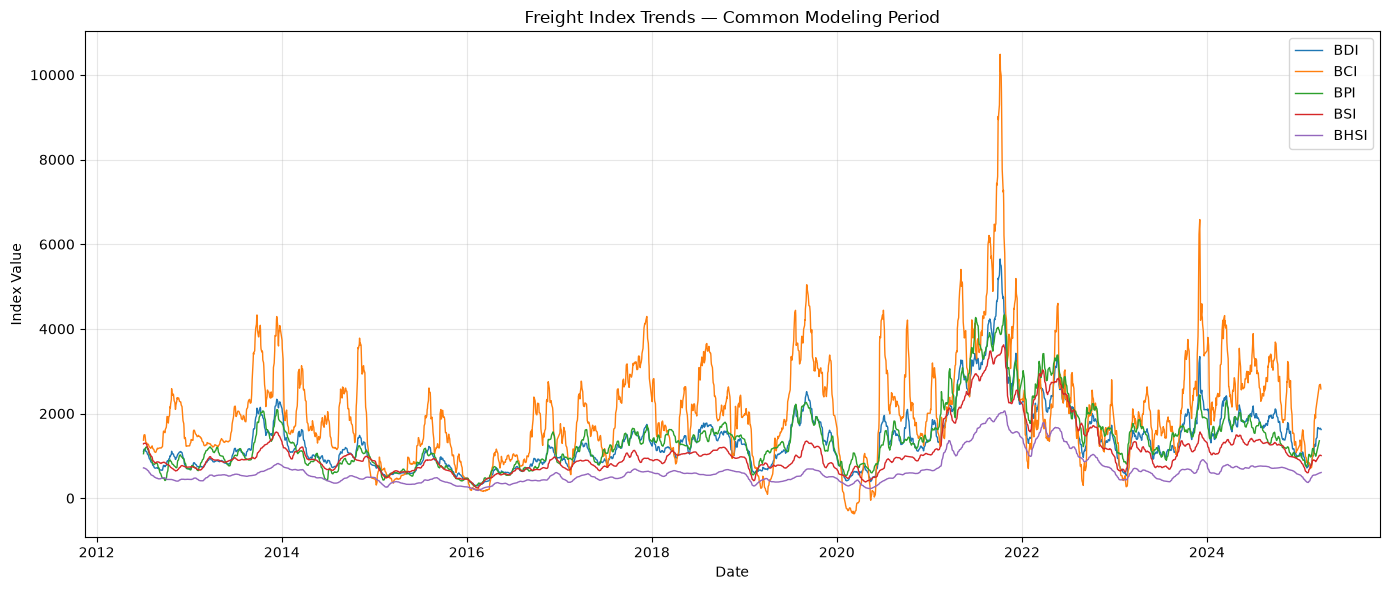

In [6]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 4: FREIGHT INDEX TRENDS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for name, df in freight_data.items():

    period_df = df[
        (df["Date"] >= COMMON_START) &
        (df["Date"] <= COMMON_END)
    ]

    plt.plot(
        period_df["Date"],
        period_df[name],
        label=name,
        linewidth=1
    )

plt.title("Freight Index Trends — Common Modeling Period")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 5: FREIGHT INDEX CORRELATION
# ============================================================

common_freight = pd.DataFrame({
    "BDI": bdi.set_index("Date")["BDI"],
    "BCI": bci.set_index("Date")["BCI"],
    "BPI": bpi.set_index("Date")["BPI"],
    "BSI": bsi.set_index("Date")["BSI"],
    "BHSI": bhsi.set_index("Date")["BHSI"]
})

common_freight = common_freight.loc[
    COMMON_START:COMMON_END
]

correlation_matrix = common_freight.corr()

display(correlation_matrix.round(3))

,BDI,BCI,BPI,BSI,BHSI
BDI,1.000,0.891,0.937,0.904,0.886
BCI,0.891,1.000,0.716,0.647,0.625
BPI,0.937,0.716,1.000,0.942,0.930
BSI,0.904,0.647,0.942,1.000,0.987
BHSI,0.886,0.625,0.930,0.987,1.000


## EDA Step 6 — Inspect Market and Commodity Data

Before combining the market variables with the freight indices, we inspect the available
Brent Crude Oil, USD/INR, Coal, and Iron Ore data.

The objective is to verify:
- Date coverage
- Number of observations
- Missing values
- Data frequency

This ensures that the external market variables are suitable for the next
feature-engineering and modeling stages.

In [11]:
# ============================================================
# LOAD USD/INR DATA
# ============================================================

usd_inr = pd.read_excel(
    PROJECT_DIR / "data" / "raw" / "market" / "USD_INR Exchange Rate.xls",
    header=0
)

usd_inr.columns = ["Date", "USD_INR"]

usd_inr["Date"] = pd.to_datetime(usd_inr["Date"], errors="coerce")
usd_inr["USD_INR"] = pd.to_numeric(usd_inr["USD_INR"], errors="coerce")

usd_inr = usd_inr.dropna()
usd_inr = usd_inr.sort_values("Date")
usd_inr = usd_inr.drop_duplicates("Date")

print("USD/INR loaded successfully")
print("Rows:", len(usd_inr))
print("Date:", usd_inr["Date"].min().date(), "→", usd_inr["Date"].max().date())
print("Missing values:", usd_inr["USD_INR"].isna().sum())

USD/INR loaded successfully
Rows: 3500
Date: 2012-01-03 → 2025-12-31
Missing values: 0


## EDA Step 7 — Monthly Commodity Data Inspection

The next step is to inspect the monthly Coal and Iron Ore data
that will be used as external market variables in Model 1.

We will extract:
- Australian Coal
- Iron Ore cfr spot

The data will then be converted into a clean monthly time-series format.

In [14]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 7: EXTRACT COAL & IRON ORE
# ============================================================

commodity_file = (
    PROJECT_DIR / "data" / "raw" / "market"
    / "Monthly Prices Coal + Iron Ore.xlsx"
)

commodity_raw = pd.read_excel(
    commodity_file,
    sheet_name="Monthly Prices",
    header=None
)

# Extract Date, Australian Coal, and Iron Ore
commodity = commodity_raw.iloc[6:, [0, 5, 63]].copy()

commodity.columns = [
    "Date",
    "Coal",
    "Iron_Ore"
]

# Convert values
commodity["Date"] = pd.to_datetime(
    commodity["Date"].astype(str),
    format="%YM%m",
    errors="coerce"
)

commodity["Coal"] = pd.to_numeric(
    commodity["Coal"],
    errors="coerce"
)

commodity["Iron_Ore"] = pd.to_numeric(
    commodity["Iron_Ore"],
    errors="coerce"
)

commodity = commodity.dropna(subset=["Date"])
commodity = commodity.sort_values("Date").reset_index(drop=True)

print("=" * 70)
print("COAL & IRON ORE DATA")
print("=" * 70)

print("Rows:", len(commodity))
print(
    "Date:",
    commodity["Date"].min().date(),
    "→",
    commodity["Date"].max().date()
)

print("\nMissing values:")
print(commodity[["Coal", "Iron_Ore"]].isna().sum())

display(commodity.head())

COAL & IRON ORE DATA
Rows: 801
Date: 1960-01-01 → 2026-09-01

Missing values:
Coal        120
Iron_Ore      0
dtype: int64


,Date,Coal,Iron_Ore
0,1960-01-01,NaN,11.4
1,1960-02-01,NaN,11.4
2,1960-03-01,NaN,11.4
3,1960-04-01,NaN,11.4
4,1960-05-01,NaN,11.4


## EDA Step 8 — Commodity Data Coverage in Modeling Period

The full commodity dataset begins in 1960, but Model 1 will use the
common period supported by the freight indices.

We therefore check Coal and Iron Ore specifically within:

2012-07-04 → 2025-03-27

This determines whether any missing values need to be handled before
feature engineering.

In [15]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 8: COMMODITY COVERAGE IN MODELING PERIOD
# ============================================================

commodity_model = commodity[
    (commodity["Date"] >= COMMON_START) &
    (commodity["Date"] <= COMMON_END)
].copy()

print("=" * 70)
print("COMMODITY DATA — MODELING PERIOD")
print("=" * 70)

print("Rows:", len(commodity_model))

print(
    "Date:",
    commodity_model["Date"].min().date(),
    "→",
    commodity_model["Date"].max().date()
)

print("\nMissing values:")
print(commodity_model[["Coal", "Iron_Ore"]].isna().sum())

print("\nMissing percentage:")
print(
    (commodity_model[["Coal", "Iron_Ore"]].isna().mean() * 100).round(2)
)

display(commodity_model.head())
display(commodity_model.tail())

COMMODITY DATA — MODELING PERIOD
Rows: 152
Date: 2012-08-01 → 2025-03-01

Missing values:
Coal        0
Iron_Ore    0
dtype: int64

Missing percentage:
Coal        0.0
Iron_Ore    0.0
dtype: float64


,Date,Coal,Iron_Ore
631,2012-08-01,91.0,107.5
632,2012-09-01,89.0,99.5
633,2012-10-01,81.9,114.0
634,2012-11-01,85.9,120.4
635,2012-12-01,92.9,128.5


,Date,Coal,Iron_Ore
778,2024-11-01,142.1,100.5
779,2024-12-01,129.8,102.2
780,2025-01-01,118.6,99.6
781,2025-02-01,106.9,105.1
782,2025-03-01,104.0,100.1


## EDA Step 9 — Market Variable Coverage in Modeling Period

Before creating the final Model 1 dataset, we verify Brent Crude Oil
and USD/INR within the common modeling period.

This ensures that all external market variables have acceptable
coverage before merging them with the freight indices.

In [17]:
# ============================================================
# LOAD BRENT CRUDE OIL DATA
# ============================================================

brent = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "market"
    / "Brent Crude Oil Price 1987-2026.csv"
)

brent = brent.rename(
    columns={
        "observation_date": "Date",
        "DCOILBRENTEU": "Brent"
    }
)

brent["Date"] = pd.to_datetime(brent["Date"], errors="coerce")
brent["Brent"] = pd.to_numeric(brent["Brent"], errors="coerce")

brent = brent.sort_values("Date").drop_duplicates("Date")

print("Brent loaded successfully")
print("Rows:", len(brent))
print(
    "Date:",
    brent["Date"].min().date(),
    "→",
    brent["Date"].max().date()
)
print("Missing:", brent["Brent"].isna().sum())

Brent loaded successfully
Rows: 10270
Date: 1987-05-20 → 2026-09-29
Missing: 1173


## EDA Step 9 — Market Variable Coverage in Modeling Period

Before creating the final Model 1 dataset, the coverage of the
external market variables is checked within the common modeling period.

The variables considered are:

- Brent Crude Oil
- USD/INR Exchange Rate

This step verifies their date range, number of observations, and
missing values before they are integrated with the freight indices
and commodity variables.`

In [18]:
# ============================================================
# FREIGHTIQ — MODEL 1
# EDA STEP 9: MARKET VARIABLE COVERAGE
# ============================================================

# ------------------------------------------------------------
# 1. Filter Brent Crude Oil data to the common modeling period
# ------------------------------------------------------------
# COMMON_START and COMMON_END represent the period supported by
# all required freight indices.

brent_model = brent[
    (brent["Date"] >= COMMON_START) &
    (brent["Date"] <= COMMON_END)
].copy()


# ------------------------------------------------------------
# 2. Filter USD/INR data to the common modeling period
# ------------------------------------------------------------
# Keeping the same date range ensures that both market variables
# are evaluated over the same period used for Model 1.

usd_inr_model = usd_inr[
    (usd_inr["Date"] >= COMMON_START) &
    (usd_inr["Date"] <= COMMON_END)
].copy()


# ------------------------------------------------------------
# 3. Display market data coverage summary
# ------------------------------------------------------------

print("=" * 70)
print("MARKET DATA — COMMON MODELING PERIOD")
print("=" * 70)


# ------------------------------------------------------------
# Brent Crude Oil summary
# ------------------------------------------------------------

print("\nBRENT CRUDE OIL")
print("-" * 40)

print("Rows:", len(brent_model))

print(
    "Date:",
    brent_model["Date"].min().date(),
    "→",
    brent_model["Date"].max().date()
)

print(
    "Missing values:",
    brent_model["Brent"].isna().sum()
)


# ------------------------------------------------------------
# USD/INR summary
# ------------------------------------------------------------

print("\nUSD/INR EXCHANGE RATE")
print("-" * 40)

print("Rows:", len(usd_inr_model))

print(
    "Date:",
    usd_inr_model["Date"].min().date(),
    "→",
    usd_inr_model["Date"].max().date()
)

print(
    "Missing values:",
    usd_inr_model["USD_INR"].isna().sum()
)


# ------------------------------------------------------------
# 4. Calculate missing-value percentages
# ------------------------------------------------------------
# This gives a clearer measure of data quality than the raw
# missing-value count alone.

print("\nMISSING VALUE PERCENTAGE")
print("-" * 40)

brent_missing_pct = (
    brent_model["Brent"].isna().mean() * 100
)

usd_inr_missing_pct = (
    usd_inr_model["USD_INR"].isna().mean() * 100
)

print(f"Brent:   {brent_missing_pct:.2f}%")
print(f"USD/INR: {usd_inr_missing_pct:.2f}%")

MARKET DATA — COMMON MODELING PERIOD

BRENT CRUDE OIL
----------------------------------------
Rows: 3322
Date: 2012-07-04 → 2025-03-27
Missing values: 91

USD/INR EXCHANGE RATE
----------------------------------------
Rows: 3181
Date: 2012-07-05 → 2025-03-27
Missing values: 0

MISSING VALUE PERCENTAGE
----------------------------------------
Brent:   2.74%
USD/INR: 0.00%
